In [3]:
import sys
import os
import pandas as pd
import pandas_datareader.data as web
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

# Add src to path for config
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), "src"))
import config

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

In [ ]:
# Define macro variables (toggleable)
macro_vars = {
    'FEDFUNDS': 'Federal Funds Rate',
    'VIXCLS': 'VIX',
    'UNRATE': 'Unemployment Rate',
    'GS10': '10-Year Treasury',
    'CPIAUCSL': 'CPI Inflation',
    'GDPC1': 'GDP',
    'DGS1MO': '1-Month Treasury',
    'DEXUSEU': 'USD/EUR Exchange Rate'
}

# Enable all by default
enabled_vars = list(macro_vars.keys())

# Date range
start_date = datetime(2011, 1, 1)
end_date = datetime(2023, 12, 31)

In [ ]:
def fetch_macro_data(vars_list, start, end):
    """Fetch macro data from FRED."""
    macro_df = pd.DataFrame()
    for var in vars_list:
        try:
            data = web.DataReader(var, 'fred', start, end)
            macro_df[var] = data[var]
            print(f"Fetched {var}")
        except Exception as e:
            print(f"Error fetching {var}: {e}")
    
    # Convert to monthly, resample quarterly if needed
    macro_df = macro_df.resample('M').last() if not macro_df.empty else macro_df
    
    # Format index to YYYYMM
    macro_df.index = macro_df.index.strftime('%Y%m').astype(int)
    return macro_df

macro_df = fetch_macro_data(enabled_vars, start_date, end_date)
print(macro_df.head())

Fetched FEDFUNDS
Fetched VIXCLS
Fetched UNRATE
Fetched GS10
Fetched CPIAUCSL
Fetched GDPC1
Fetched DGS1MO
Fetched DEXUSEU
        FEDFUNDS  VIXCLS  UNRATE  GS10  CPIAUCSL      GDPC1  DGS1MO  DEXUSEU
DATE                                                                        
201101      0.17     NaN     9.1  3.39   221.187  16920.632     NaN      NaN
201102      0.16   17.63     9.0  3.58   221.898        NaN    0.16   1.3793
201103      0.14   21.01     9.0  3.41   223.046        NaN    0.07   1.3813
201104      0.10   17.40     9.1  3.46   224.093  17035.114    0.03   1.4215
201105      0.09     NaN     9.0  3.17   224.806        NaN     NaN      NaN


In [ ]:
FACTORS_DIR = 'data/factors' # Change to 'data/factors_with_ETFs' to use ETF models
# Load factor CSVs from data/factors/
factors_dir = Path(FACTORS_DIR)
factor_files = list(factors_dir.glob('*_factors.csv'))
factor_dfs = {}
for file in factor_files:
    name = file.stem.replace('_factors', '')
    df = pd.read_csv(file, index_col='date')
    factor_dfs[name] = df
    print(f"Loaded {name}")

print(f"Loaded {len(factor_dfs)} factor CSVs")

Loaded CA0_K5
Loaded CA2_K5
Loaded 2 factor CSVs


In [ ]:
# Merge and handle missing data
results = {}
for name, factor_df in factor_dfs.items():
    combined = factor_df.merge(macro_df, left_index=True, right_index=True, how='inner')
    missing_pct = combined.isnull().mean().mean() * 100
    if missing_pct < 5:
        combined = combined.dropna()
        print(f"{name}: Dropped {missing_pct:.1f}% missing data")
    else:
        print(f"{name}: High missing data ({missing_pct:.1f}%), consider interpolation")
        combined = combined.interpolate(method='linear').dropna()
    
    # Normalize factors and macros for comparability
    for col in combined.columns:
        if col.startswith('Factor_'):
            combined[col] = (combined[col] - combined[col].mean()) / combined[col].std()
        elif col in macro_vars:
            combined[col] = (combined[col] - combined[col].mean()) / combined[col].std()
    
    results[name] = combined

print("Merged and normalized data")

CA0_K5: High missing data (13.1%), consider interpolation
CA2_K5: High missing data (13.1%), consider interpolation
Merged and normalized data


In [ ]:
# Compute correlations
correlations = {}
for name, df in results.items():
    corr = df.corr()
    correlations[name] = corr
    print(f"{name} correlations:\n{corr.loc[['Factor_1', 'Factor_2', 'Factor_3', 'Factor_4', 'Factor_5'], enabled_vars]}")

# Compute rankings of top correlated macros per factor using absolute values
rankings = {}
for name, corr in correlations.items():
    rankings[name] = {}
    for factor in [c for c in corr.columns if c.startswith('Factor_')]:
        abs_corr = corr.loc[factor, enabled_vars].abs().sort_values(ascending=False)
        top_macros = abs_corr.head(3).index.tolist()
        rankings[name][factor] = top_macros
        print(f"{name} {factor} top 3 macros by abs corr: {top_macros}")

# Save summary
summary = pd.DataFrame()
for name, corr in correlations.items():
    for factor in [c for c in corr.columns if c.startswith('Factor_')]:
        for macro in enabled_vars:
            summary.loc[f"{name}_{factor}", macro] = corr.loc[factor, macro]

summary.to_csv(config.TABLE_DIR + 'factor_macro_correlations.csv')
print("Saved correlations to tables/factor_macro_correlations.csv")

CA0_K5 correlations:
          FEDFUNDS    VIXCLS    UNRATE      GS10  CPIAUCSL     GDPC1  \
Factor_1 -0.148215 -0.023749  0.301492 -0.247538 -0.115845 -0.081615   
Factor_2  0.094346 -0.049297 -0.260439  0.226201  0.065148  0.037392   
Factor_3  0.024250  0.017855 -0.215983  0.100833  0.042723  0.029194   
Factor_4  0.132262 -0.079010 -0.227824  0.260503  0.087400  0.054358   
Factor_5  0.012290  0.014210  0.178107 -0.089693 -0.001651  0.010109   

            DGS1MO   DEXUSEU  
Factor_1 -0.133116  0.117307  
Factor_2  0.083354 -0.051314  
Factor_3  0.006845 -0.015510  
Factor_4  0.130322 -0.007783  
Factor_5  0.028901 -0.000847  
CA2_K5 correlations:
          FEDFUNDS    VIXCLS    UNRATE      GS10  CPIAUCSL     GDPC1  \
Factor_1  0.039465  0.045943 -0.241510  0.101768  0.053460  0.039022   
Factor_2  0.007059  0.090913  0.110539 -0.156940  0.019695  0.036627   
Factor_3  0.017584  0.022924 -0.199260  0.096069  0.019886  0.006506   
Factor_4 -0.244369 -0.021432  0.252577 -0.274609 -0


CA0_K5 - Factor_3 compared to GS10 and VIXCLS:
  GS10: raw=0.1008, abs=0.1008
  VIXCLS: raw=0.0179, abs=0.0179
  Factor_3 top 3 by abs corr: ['UNRATE', 'GS10', 'CPIAUCSL']

CA2_K5 - Factor_3 compared to GS10 and VIXCLS:
  GS10: raw=0.0961, abs=0.0961
  VIXCLS: raw=0.0229, abs=0.0229
  Factor_3 top 3 by abs corr: ['UNRATE', 'GS10', 'VIXCLS']


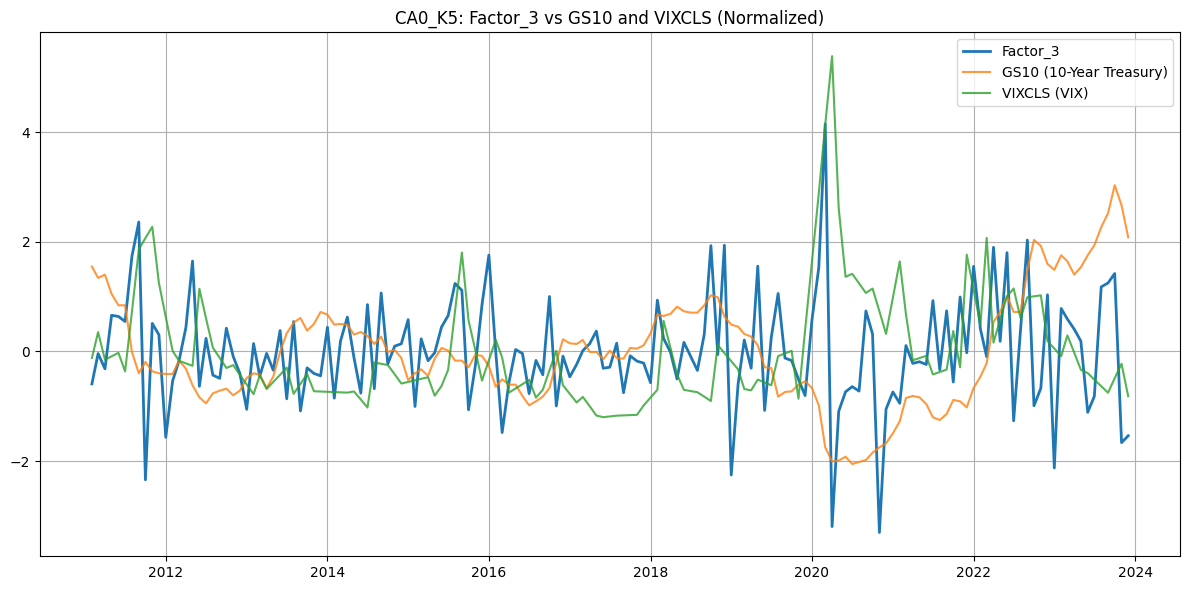

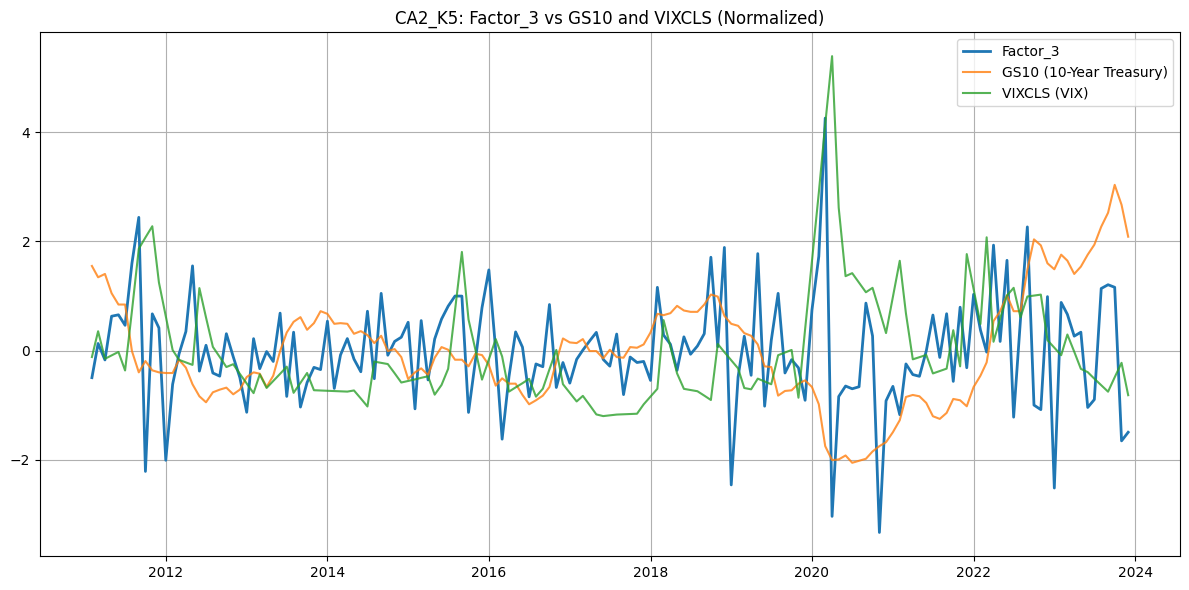

In [ ]:
# Compare Factor_3 specifically with Treasury and VIX
for name, corr in correlations.items():
    if 'Factor_3' in corr.index:
        print(f"\n{name} - Factor_3 compared to GS10 and VIXCLS:")
        for macro in ['GS10', 'VIXCLS']:
            if macro in corr.columns:
                value = corr.loc['Factor_3', macro]
                print(f"  {macro}: raw={value:.4f}, abs={abs(value):.4f}")
        print(f"  Factor_3 top 3 by abs corr: {rankings[name]['Factor_3']}")

# Plot Factor_3 vs GS10 and VIXCLS directly for visual comparison
for name, df in results.items():
    df_plot = df.copy()
    df_plot.index = pd.to_datetime(df_plot.index.astype(str), format='%Y%m')
    if 'Factor_3' not in df_plot.columns:
        continue

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df_plot.index, df_plot['Factor_3'], label='Factor_3', linewidth=2)
    for macro in ['GS10', 'VIXCLS']:
        if macro in df_plot.columns:
            ax.plot(df_plot.index, df_plot[macro], label=f"{macro} ({macro_vars[macro]})", alpha=0.8)
    ax.set_title(f"{name}: Factor_3 vs GS10 and VIXCLS (Normalized)")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


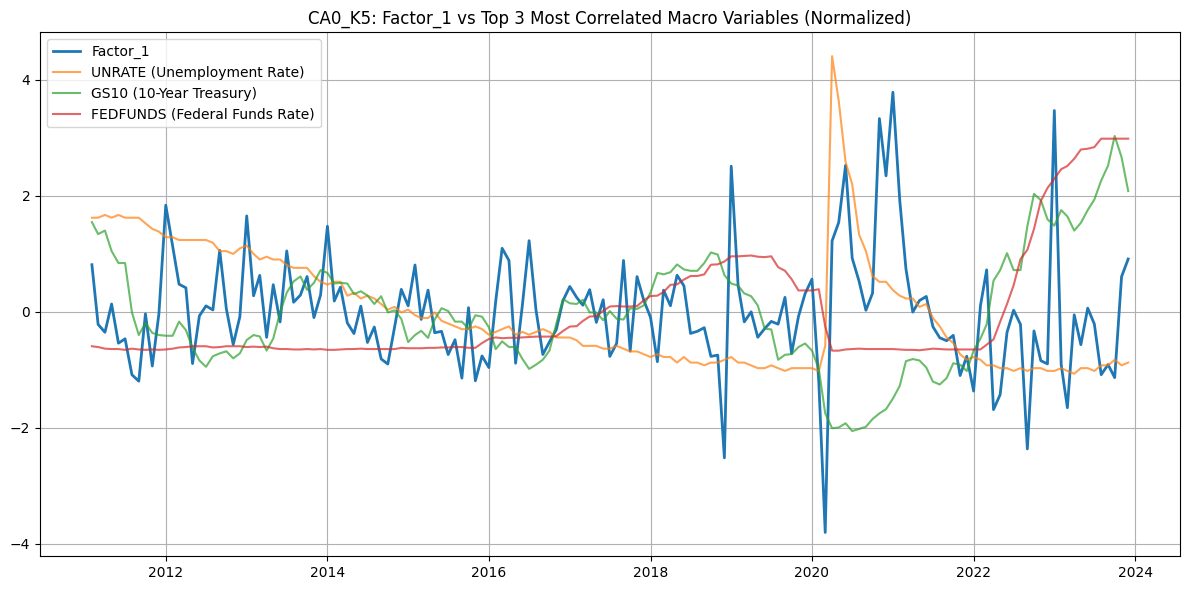

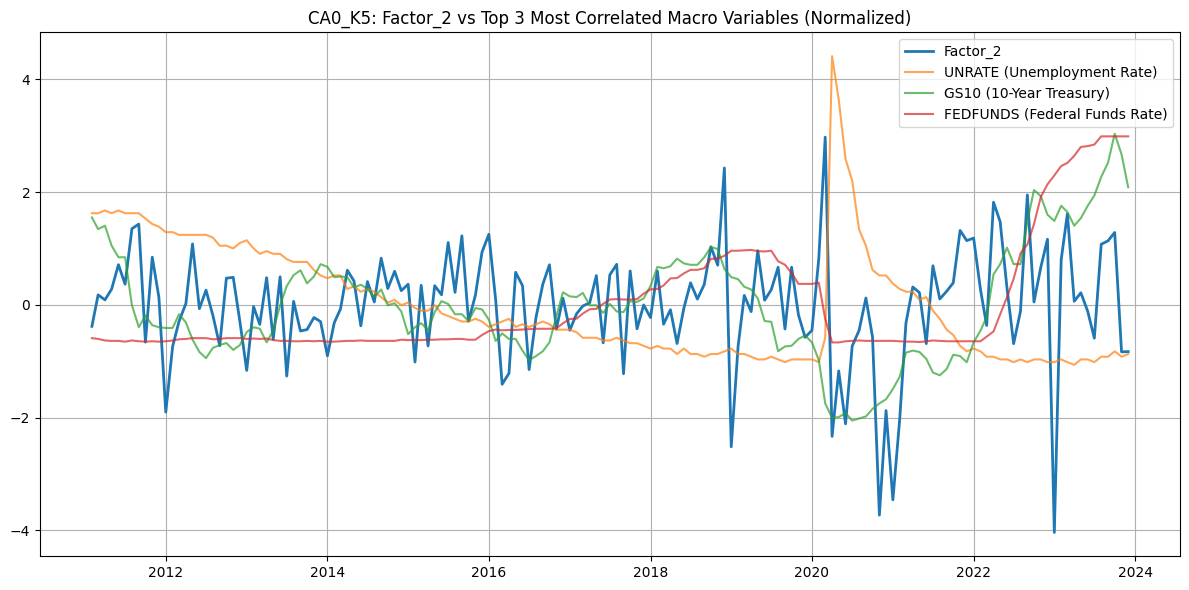

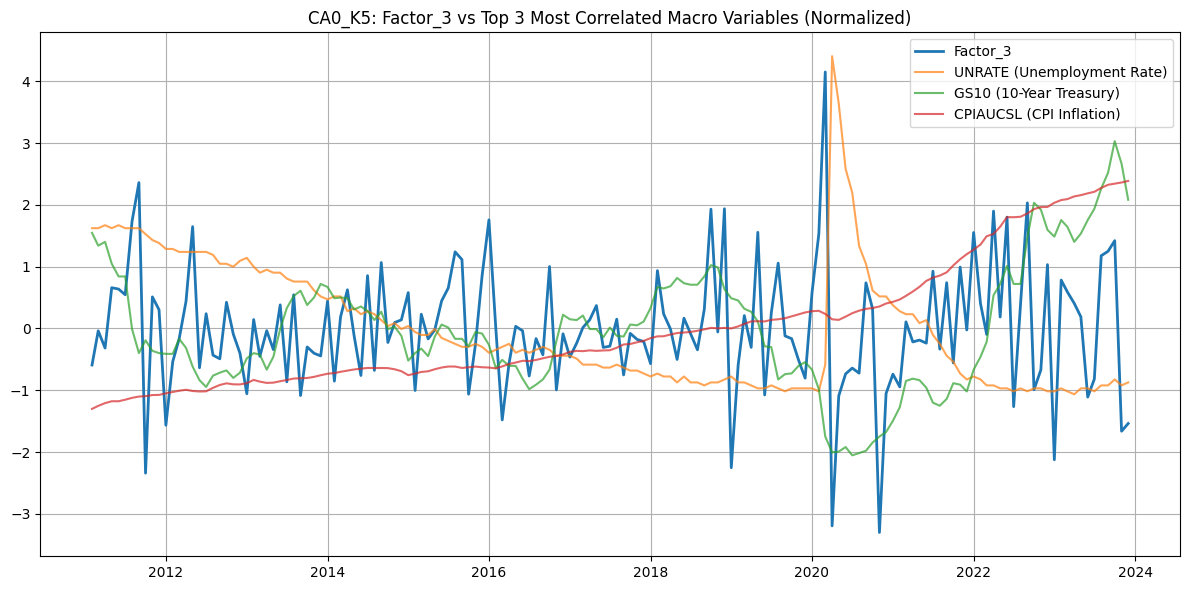

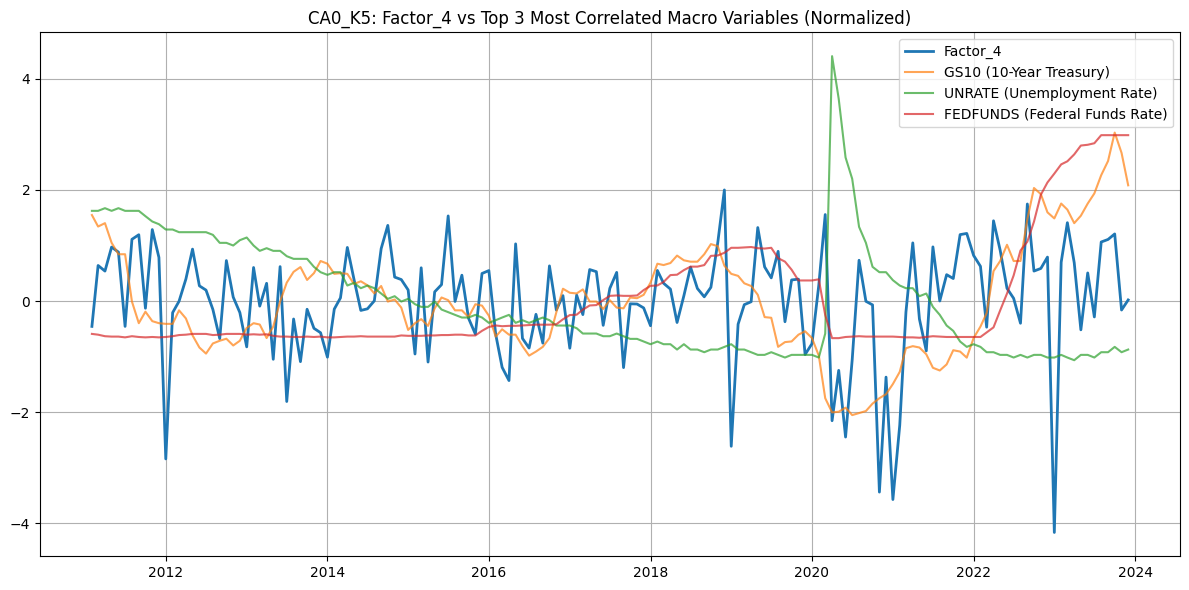

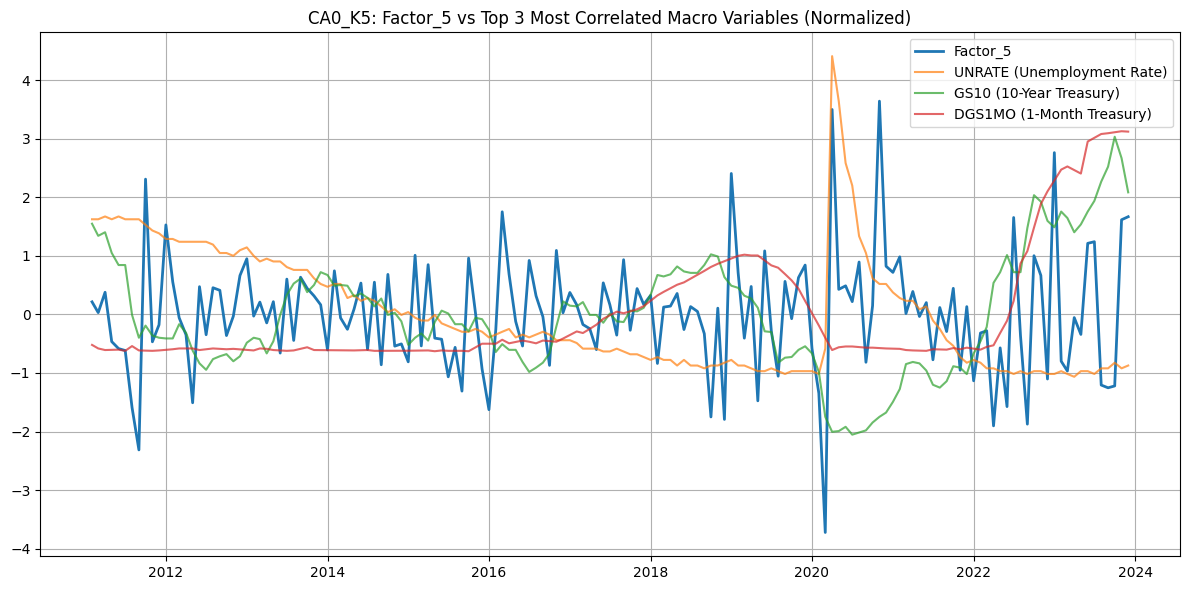

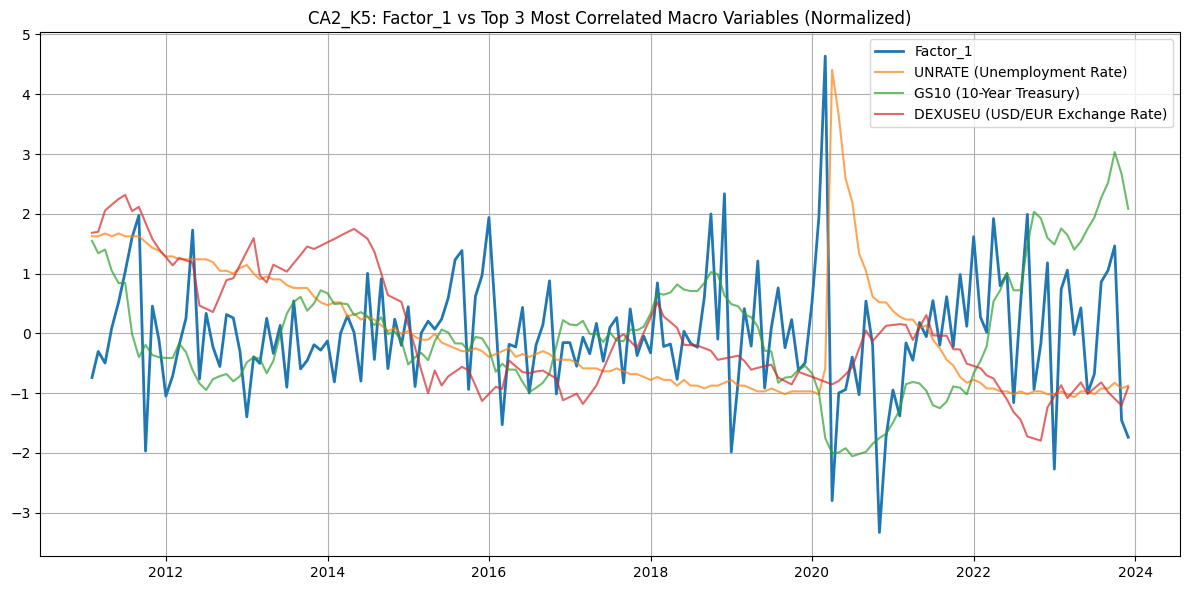

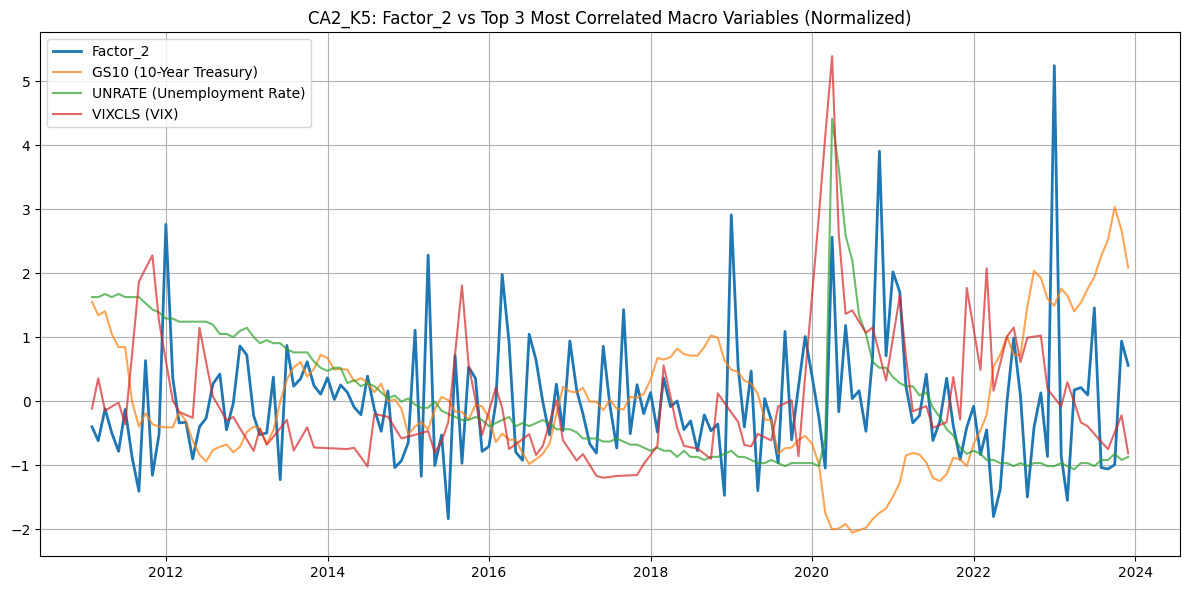

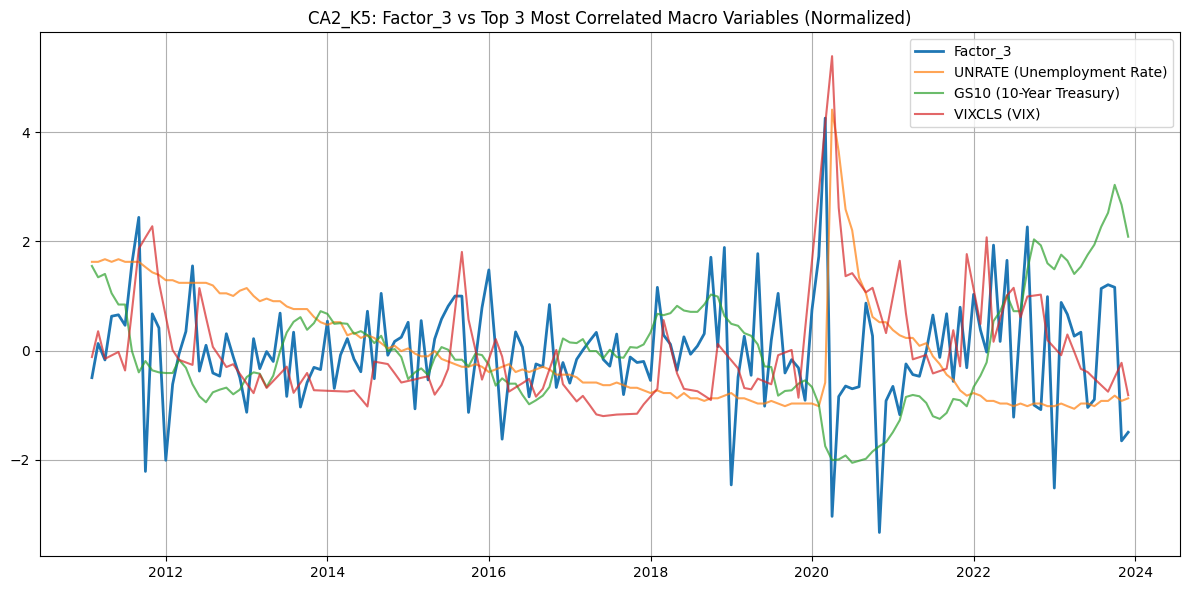

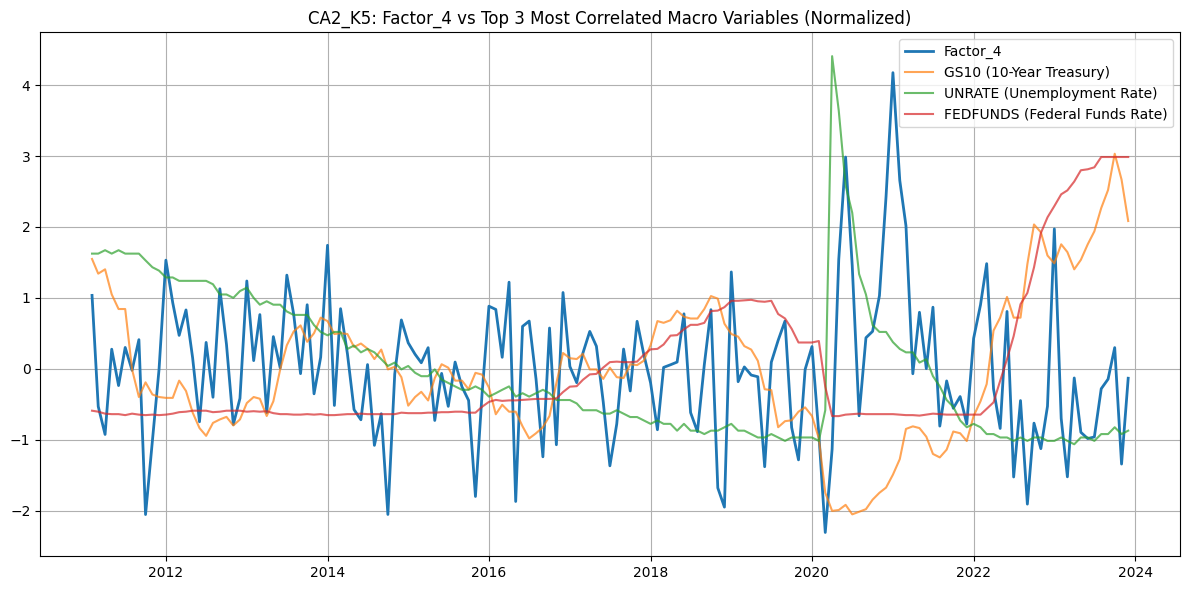

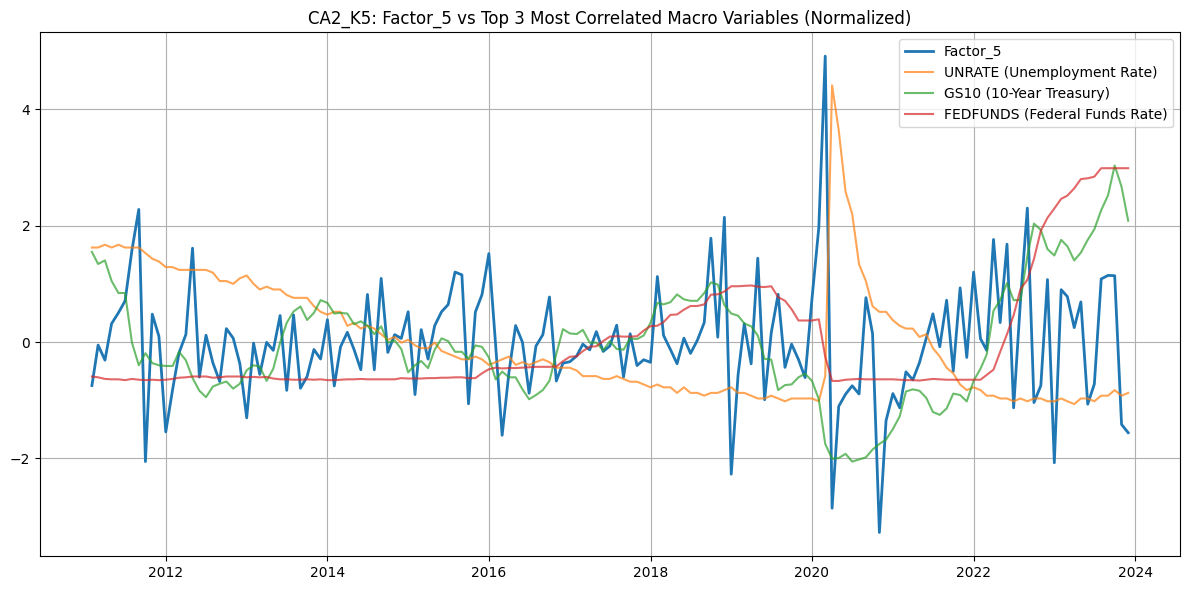

Plots displayed


In [ ]:
# Plot time series overlays
for name, df in results.items():
    df_plot = df.copy()
    df_plot.index = pd.to_datetime(df_plot.index.astype(str), format='%Y%m')
    
    for factor in [c for c in df.columns if c.startswith('Factor_')]:
        top_3_macros = rankings[name][factor]  # Use the rankings
        
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(df_plot.index, df_plot[factor], label=factor, linewidth=2)
        for macro in top_3_macros:
            if macro in df.columns:
                ax.plot(df_plot.index, df_plot[macro], label=f"{macro} ({macro_vars[macro]})", alpha=0.7)
        ax.set_title(f"{name}: {factor} vs Top 3 Most Correlated Macro Variables (Normalized)")
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        # Removed plt.savefig to avoid clutter
        plt.show()

print("Plots displayed")